 ## Imports libraries

In [11]:

import os
import numpy as np
import cv2
from pathlib import Path
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import accuracy_score, roc_curve, auc
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import pickle
import warnings
import pandas as pd
warnings.filterwarnings('ignore')

# Налаштування візуалізації
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Бібліотеки імпортовані успішно")

✓ Бібліотеки імпортовані успішно


## Settings path

In [12]:
DATASET_ROOT = Path("./datasets/replay_attack") 
CSV_FILE = Path("./datasets/replay_attack/anti-spoofing.csv")  

if not CSV_FILE.exists():
    raise FileNotFoundError(f"CSV файл не знайдено: {CSV_FILE}")
if not DATASET_ROOT.exists():
    raise FileNotFoundError(f"Папка датасету не знайдена: {DATASET_ROOT}")

print(f"✓ CSV файл: {CSV_FILE}")
print(f"✓ Dataset root: {DATASET_ROOT}")

✓ CSV файл: datasets/replay_attack/anti-spoofing.csv
✓ Dataset root: datasets/replay_attack


## Download dataset


In [14]:
df = pd.read_csv(CSV_FILE)

print(f"\n📊 Dataset Statistics:")
print(f"  Rows: {len(df)}")
print(f"  Columns: {df.columns.tolist()}")

# Структура: live_selfie, live_video = REAL (label 0)
#            cut-out_printouts, printouts, replay = ATTACK (label 1)

real_columns = ['live_selfie', 'live_video']
attack_columns = ['cut-out_printouts', 'printouts', 'replay']

print(f"\n✓ Real types: {real_columns}")
print(f"✓ Attack types: {attack_columns}")


📊 Dataset Statistics:
  Rows: 9
  Columns: ['live_selfie', 'live_video', 'cut-out_printouts', 'printouts', 'replay']

✓ Real types: ['live_selfie', 'live_video']
✓ Attack types: ['cut-out_printouts', 'printouts', 'replay']


## Creating list files with labels

In [15]:
def collect_video_paths(df, columns, label):
    video_paths = []
    labels = []
    
    for col in columns:
        if col in df.columns:
            for video_file in df[col].dropna():
                video_path = DATASET_ROOT / video_file
                if video_path.exists():
                    video_paths.append(video_path)
                    labels.append(label)
    
    return video_paths, labels


real_videos, real_labels = collect_video_paths(df, real_columns, label=0)

attack_videos, attack_labels = collect_video_paths(df, attack_columns, label=1)

print(f"\n📹 Video Files:")
print(f"  Real videos: {len(real_videos)}")
print(f"  Attack videos: {len(attack_videos)}")
print(f"  Total: {len(real_videos) + len(attack_videos)}")

all_videos = real_videos + attack_videos
all_labels = real_labels + attack_labels

print(f"\n✓ Dataset prepared: {len(all_videos)} videos")


📹 Video Files:
  Real videos: 9
  Attack videos: 26
  Total: 35

✓ Dataset prepared: 35 videos


## Train/Test Split

In [16]:
from sklearn.model_selection import train_test_split

train_videos, test_videos, train_labels, test_labels = train_test_split(
    all_videos, 
    all_labels,
    test_size=0.2,
    random_state=42,
    stratify=all_labels 
)

print(f"\n🔀 Train/Test Split:")
print(f"  Train: {len(train_videos)} videos ({sum(1 for l in train_labels if l==0)} real, {sum(1 for l in train_labels if l==1)} attack)")
print(f"  Test:  {len(test_videos)} videos ({sum(1 for l in test_labels if l==0)} real, {sum(1 for l in test_labels if l==1)} attack)")


🔀 Train/Test Split:
  Train: 28 videos (7 real, 21 attack)
  Test:  7 videos (2 real, 5 attack)


## Extract frames from video

In [ ]:
def extract_frames_from_video(video_path, num_frames=10, target_size=(64, 64)):
    """
    Args:
        video_path: Шлях до відео
        num_frames: Скільки кадрів взяти (рівномірно розподілених)
        target_size: Розмір кадру для resize
        
    Returns:
        List of frames (numpy arrays)
    """
    cap = cv2.VideoCapture(str(video_path))
    
    if not cap.isOpened():
        print(f"⚠️  Не вдалося відкрити: {video_path.name}")
        return []
    
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    if total_frames == 0:
        cap.release()
        return []
    
    frame_indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)
    
    frames = []
    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        
        if ret:
            frame = cv2.resize(frame, target_size)
            frames.append(frame)
    
    cap.release()
    return frames

def extract_frames_batch(video_paths, num_frames=10, target_size=(64, 64)):
    """Екстрагує кадри з батчу відео"""
    all_frames = []
    labels_expanded = []
    
    for i, video_path in enumerate(tqdm(video_paths, desc="Екстракція кадрів")):
        frames = extract_frames_from_video(video_path, num_frames, target_size)
        
        if len(frames) > 0:
            all_frames.extend(frames)
            labels_expanded.extend([None] * len(frames)) 
    
    return all_frames, labels_expanded

print("\n🎬 Екстракція кадрів з відео...")
print("  Параметри: 10 кадрів на відео, розмір 64x64")


🎬 Екстракція кадрів з відео...
  Параметри: 10 кадрів на відео, розмір 64x64


## Train set

In [18]:
print("\n📁 Обробка Train Set...")

NUM_FRAMES_PER_VIDEO = 10

train_frames = []
train_frame_labels = []

for video_path, label in tqdm(zip(train_videos, train_labels), 
                              total=len(train_videos),
                              desc="Train videos"):
    frames = extract_frames_from_video(video_path, 
                                      num_frames=NUM_FRAMES_PER_VIDEO,
                                      target_size=(64, 64))
    
    if len(frames) > 0:
        train_frames.extend(frames)
        train_frame_labels.extend([label] * len(frames))

train_frames = np.array(train_frames)
train_frame_labels = np.array(train_frame_labels)

print(f"\n✓ Train frames: {len(train_frames)}")
print(f"  Real: {sum(train_frame_labels == 0)}")
print(f"  Attack: {sum(train_frame_labels == 1)}")


📁 Обробка Train Set...


0.00s - Debugger warning: It seems that frozen modules are being used, which may
0.00s - make the debugger miss breakpoints. Please pass -Xfrozen_modules=off
0.00s - to python to disable frozen modules.
0.00s - Note: Debugging will proceed. Set PYDEVD_DISABLE_FILE_VALIDATION=1 to disable this validation.


Train videos:   0%|          | 0/28 [00:00<?, ?it/s]


✓ Train frames: 278
  Real: 70
  Attack: 208


## Test set

In [19]:
print("\n📁 Обробка Test Set...")

test_frames = []
test_frame_labels = []

for video_path, label in tqdm(zip(test_videos, test_labels), 
                             total=len(test_videos),
                             desc="Test videos"):
    frames = extract_frames_from_video(video_path, 
                                      num_frames=NUM_FRAMES_PER_VIDEO,
                                      target_size=(64, 64))
    
    if len(frames) > 0:
        test_frames.extend(frames)
        test_frame_labels.extend([label] * len(frames))

test_frames = np.array(test_frames)
test_frame_labels = np.array(test_frame_labels)

print(f"\n✓ Test frames: {len(test_frames)}")
print(f"  Real: {sum(test_frame_labels == 0)}")
print(f"  Attack: {sum(test_frame_labels == 1)}")


📁 Обробка Test Set...


Test videos:   0%|          | 0/7 [00:00<?, ?it/s]


✓ Test frames: 70
  Real: 20
  Attack: 50


## LBP

In [20]:
class LBPDescriptor:
    def __init__(self, num_points=8, radius=1):
        self.num_points = num_points
        self.radius = radius
        self.n_bins = num_points + 2  
        
    def _get_pixel(self, img, center, x, y):
        new_x = center[0] + x
        new_y = center[1] + y
        
        if new_x < 0 or new_y < 0 or new_x >= img.shape[0] or new_y >= img.shape[1]:
            return 0
        
        return int(img[new_x, new_y])
    
    def _lbp_calculated_pixel(self, img, x, y):
        center = [x, y]
        center_value = img[x, y]
        
        lbp_code = 0
        for i in range(self.num_points):
            angle = 2 * np.pi * i / self.num_points
            x_offset = self.radius * np.cos(angle)
            y_offset = -self.radius * np.sin(angle)
            
            neighbor_value = self._get_pixel(img, center, int(x_offset), int(y_offset))
            
            if neighbor_value >= center_value:
                lbp_code |= (1 << i)
        
        return lbp_code
    
    def extract(self, image):
        """
        Args:
            image: BGR зображення (OpenCV format)
            
        Returns:
            hist: Нормалізована гістограма LBP
        """
        # Конвертація в grayscale
        if len(image.shape) == 3:
            gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        else:
            gray = image
        
        # Обчислення LBP карти
        height, width = gray.shape
        lbp_image = np.zeros_like(gray)
        
        for i in range(self.radius, height - self.radius):
            for j in range(self.radius, width - self.radius):
                lbp_image[i, j] = self._lbp_calculated_pixel(gray, i, j)
        
        # Гістограма
        hist, _ = np.histogram(lbp_image.ravel(), 
                               bins=self.n_bins, 
                               range=(0, self.n_bins))
        
        # Нормалізація
        hist = hist.astype("float")
        hist /= (hist.sum() + 1e-7)
        
        return hist

# Тестування LBP
lbp_extractor = LBPDescriptor(num_points=8, radius=1)
print(f"\n✓ LBP екстрактор ініціалізовано: {lbp_extractor.n_bins} bins")


✓ LBP екстрактор ініціалізовано: 10 bins


## Extarct LBP feats

In [21]:
def extract_features_batch(frames, extractor):
    features = []
    for frame in tqdm(frames, desc="Екстракція LBP"):
        feat = extractor.extract(frame)
        features.append(feat)
    return np.array(features)

print("\n🔍 Екстракція LBP дескрипторів з кадрів...")

X_train = extract_features_batch(train_frames, lbp_extractor)
y_train = train_frame_labels

X_test = extract_features_batch(test_frames, lbp_extractor)
y_test = test_frame_labels

print(f"\n✓ Train features: {X_train.shape}")
print(f"✓ Test features: {X_test.shape}")
print(f"  Feature dimension: {X_train.shape[1]} bins")


🔍 Екстракція LBP дескрипторів з кадрів...


Екстракція LBP:   0%|          | 0/278 [00:00<?, ?it/s]

Екстракція LBP:   0%|          | 0/70 [00:00<?, ?it/s]


✓ Train features: (278, 10)
✓ Test features: (70, 10)
  Feature dimension: 10 bins


## Norm date

In [22]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✓ Дані нормалізовано (StandardScaler)")

✓ Дані нормалізовано (StandardScaler)


## Learning SVM

In [23]:
print("\n🤖 Навчання SVM з RBF kernel...")

svm_model = SVC(
    kernel='rbf',
    C=10.0,
    gamma='scale',
    probability=True,
    random_state=42,
    verbose=True
)

svm_model.fit(X_train_scaled, y_train)

print("✓ SVM навчено успішно")
print(f"  Support vectors: {svm_model.n_support_}")


🤖 Навчання SVM з RBF kernel...
[LibSVM]*
optimization finished, #iter = 53
obj = -1060.000000, rho = -1.000000
nSV = 106, nBSV = 106
Total nSV = 106
*
optimization finished, #iter = 55
obj = -1100.000000, rho = -1.000000
nSV = 110, nBSV = 110
Total nSV = 110
*
optimization finished, #iter = 60
obj = -1200.000000, rho = -1.000000
nSV = 120, nBSV = 120
Total nSV = 120
*
optimization finished, #iter = 56
obj = -1120.000000, rho = -1.000000
nSV = 112, nBSV = 112
Total nSV = 112
*
optimization finished, #iter = 56
obj = -1120.000000, rho = -1.000000
nSV = 112, nBSV = 112
Total nSV = 112
*
optimization finished, #iter = 70
obj = -1400.000000, rho = 1.000000
nSV = 140, nBSV = 140
Total nSV = 140
✓ SVM навчено успішно
  Support vectors: [70 70]


## Evaluation models on cadrs level

In [24]:
# Prediction
y_train_pred = svm_model.predict(X_train_scaled)
y_test_pred = svm_model.predict(X_test_scaled)

# Accuracy
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"\n📊 Frame-level Accuracy:")
print(f"  Train: {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"  Test:  {test_acc:.4f} ({test_acc*100:.2f}%)")

# Prediction scores для ROC
y_train_scores = svm_model.predict_proba(X_train_scaled)[:, 1]
y_test_scores = svm_model.predict_proba(X_test_scaled)[:, 1]


📊 Frame-level Accuracy:
  Train: 0.7482 (74.82%)
  Test:  0.7143 (71.43%)


## Video-level Prediction

In [25]:
def aggregate_video_predictions(video_paths, video_labels, frame_scores, num_frames_per_video):
    """
    Агрегує prediction scores на рівні відео.
    Використовує average pooling по кадрам одного відео.
    """
    video_scores = []
    video_true_labels = []
    
    frame_idx = 0
    for i, (video_path, label) in enumerate(zip(video_paths, video_labels)):
        video_frame_scores = frame_scores[frame_idx:frame_idx + num_frames_per_video]
        
        if len(video_frame_scores) > 0:
            avg_score = np.mean(video_frame_scores)
            video_scores.append(avg_score)
            video_true_labels.append(label)
        
        frame_idx += num_frames_per_video
    
    return np.array(video_scores), np.array(video_true_labels)

print("\n🎬 Video-level aggregation...")

test_video_scores, test_video_labels = aggregate_video_predictions(
    test_videos,
    test_labels,
    y_test_scores,
    NUM_FRAMES_PER_VIDEO
)

test_video_preds = (test_video_scores >= 0.5).astype(int)
video_acc = accuracy_score(test_video_labels, test_video_preds)

print(f"\n📊 Video-level Accuracy: {video_acc:.4f} ({video_acc*100:.2f}%)")


🎬 Video-level aggregation...

📊 Video-level Accuracy: 0.7143 (71.43%)


## Calculating EER, HTER

In [26]:
def compute_eer(y_true, y_scores):
    """Обчислення Equal Error Rate"""
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    fnr = 1 - tpr
    
    eer_threshold = thresholds[np.nanargmin(np.absolute((fnr - fpr)))]
    eer = fpr[np.nanargmin(np.absolute((fnr - fpr)))]
    
    return eer, eer_threshold

def compute_hter(y_true, y_scores, threshold):
    """Обчислення Half Total Error Rate"""
    y_pred = (y_scores >= threshold).astype(int)
    
    # FAR - attack classified as real
    far = np.sum((y_pred == 0) & (y_true == 1)) / np.sum(y_true == 1)
    
    # FRR - real classified as attack
    frr = np.sum((y_pred == 1) & (y_true == 0)) / np.sum(y_true == 0)
    
    hter = (far + frr) / 2
    return hter, far, frr

# Метрики на video-level
test_eer, test_eer_threshold = compute_eer(test_video_labels, test_video_scores)
test_hter, test_far, test_frr = compute_hter(test_video_labels, test_video_scores, test_eer_threshold)

print(f"\n🎯 Video-level Metrics:")
print(f"  EER:  {test_eer:.4f} ({test_eer*100:.2f}%)")
print(f"  HTER: {test_hter:.4f} ({test_hter*100:.2f}%)")
print(f"  FAR:  {test_far:.4f} ({test_far*100:.2f}%)")
print(f"  FRR:  {test_frr:.4f} ({test_frr*100:.2f}%)")
print(f"  EER Threshold: {test_eer_threshold:.4f}")


🎯 Video-level Metrics:
  EER:  0.0000 (0.00%)
  HTER: 0.5000 (50.00%)
  FAR:  1.0000 (100.00%)
  FRR:  0.0000 (0.00%)
  EER Threshold: inf


## ROC curve

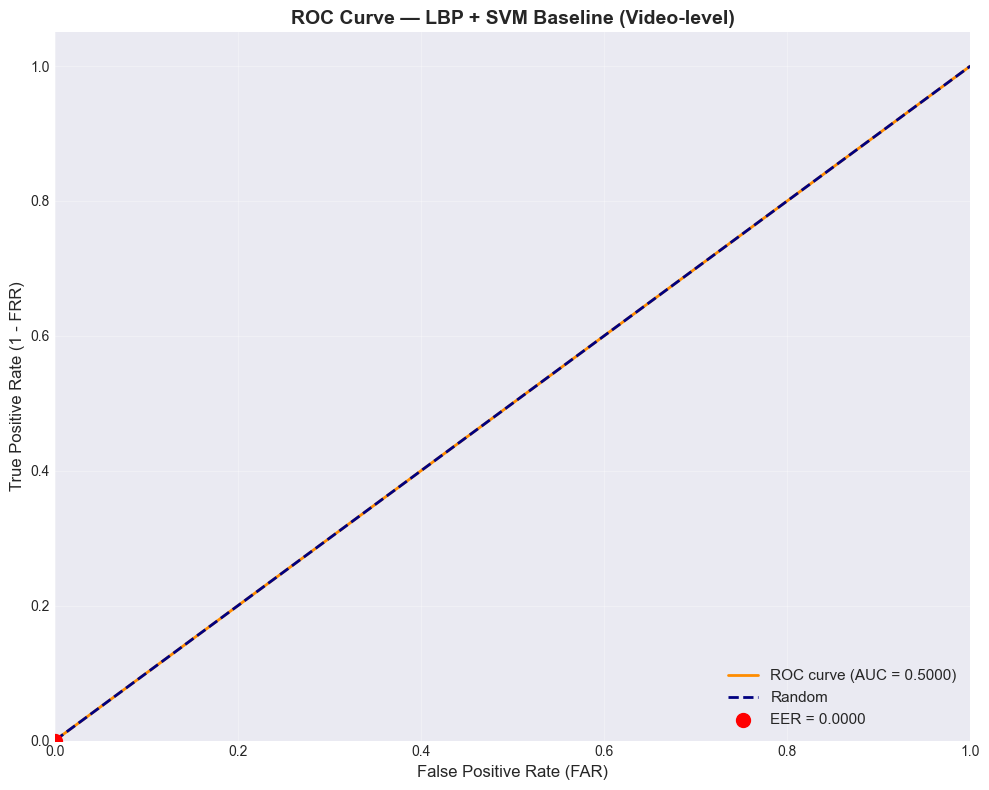

✓ ROC крива збережена: lbp_svm_roc_curve.png


In [27]:
fpr, tpr, thresholds = roc_curve(test_video_labels, test_video_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')

eer_fpr = fpr[np.nanargmin(np.absolute(((1-tpr) - fpr)))]
eer_tpr = tpr[np.nanargmin(np.absolute(((1-tpr) - fpr)))]
plt.scatter(eer_fpr, eer_tpr, color='red', s=100, zorder=5,
            label=f'EER = {test_eer:.4f}')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FAR)', fontsize=12)
plt.ylabel('True Positive Rate (1 - FRR)', fontsize=12)
plt.title('ROC Curve — LBP + SVM Baseline (Video-level)', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('lbp_svm_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ ROC крива збережена: lbp_svm_roc_curve.png")

## Confusion Matrix

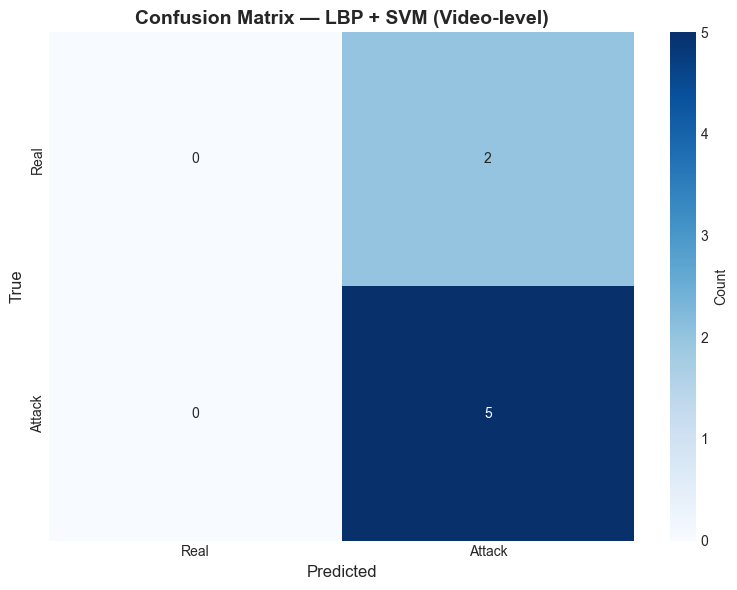

✓ Confusion Matrix збережена: lbp_svm_confusion_matrix.png


In [28]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(test_video_labels, test_video_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Real', 'Attack'],
            yticklabels=['Real', 'Attack'],
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.title('Confusion Matrix — LBP + SVM (Video-level)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('lbp_svm_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Confusion Matrix збережена: lbp_svm_confusion_matrix.png")

## Visualization LBP descriptors

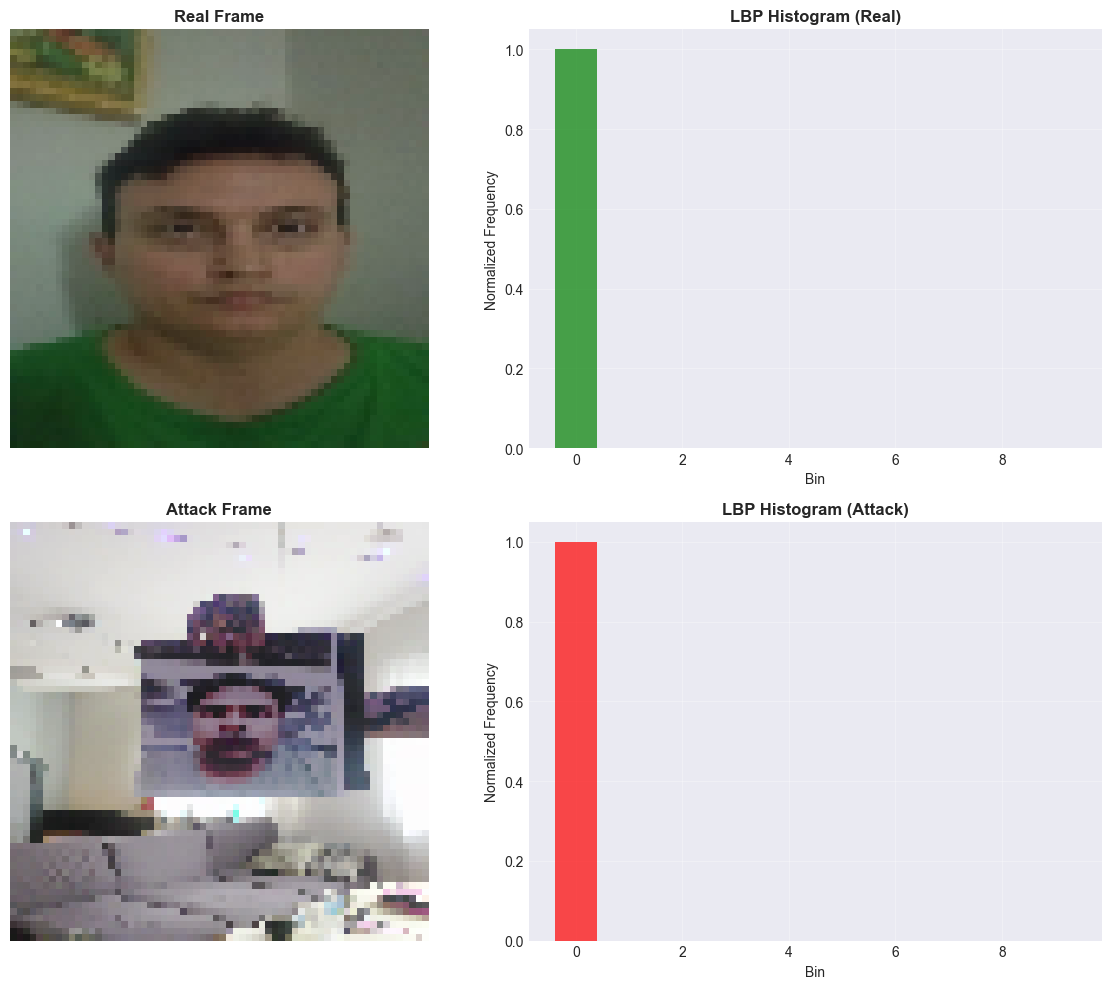

✓ LBP візуалізація збережена: lbp_visualization.png


In [29]:
sample_real = train_frames[train_frame_labels == 0][0]
sample_attack = train_frames[train_frame_labels == 1][0]

lbp_real = lbp_extractor.extract(sample_real)
lbp_attack = lbp_extractor.extract(sample_attack)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].imshow(cv2.cvtColor(sample_real, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title('Real Frame', fontsize=12, fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].bar(range(len(lbp_real)), lbp_real, color='green', alpha=0.7)
axes[0, 1].set_title('LBP Histogram (Real)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Bin')
axes[0, 1].set_ylabel('Normalized Frequency')
axes[0, 1].grid(alpha=0.3)

axes[1, 0].imshow(cv2.cvtColor(sample_attack, cv2.COLOR_BGR2RGB))
axes[1, 0].set_title('Attack Frame', fontsize=12, fontweight='bold')
axes[1, 0].axis('off')

axes[1, 1].bar(range(len(lbp_attack)), lbp_attack, color='red', alpha=0.7)
axes[1, 1].set_title('LBP Histogram (Attack)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Bin')
axes[1, 1].set_ylabel('Normalized Frequency')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('lbp_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ LBP візуалізація збережена: lbp_visualization.png")

## Saving model

In [30]:
model_data = {
    'svm_model': svm_model,
    'scaler': scaler,
    'lbp_params': {
        'num_points': lbp_extractor.num_points,
        'radius': lbp_extractor.radius
    },
    'num_frames_per_video': NUM_FRAMES_PER_VIDEO,
    'results': {
        'frame_level': {
            'test_accuracy': test_acc,
        },
        'video_level': {
            'test_accuracy': video_acc,
            'test_eer': test_eer,
            'test_hter': test_hter,
            'test_far': test_far,
            'test_frr': test_frr,
            'roc_auc': roc_auc,
            'eer_threshold': test_eer_threshold
        }
    }
}

with open('lbp_svm_model.pkl', 'wb') as f:
    pickle.dump(model_data, f)

print("✓ Модель збережена: lbp_svm_model.pkl")

✓ Модель збережена: lbp_svm_model.pkl


## Final Report

In [31]:
print("\n" + "="*60)
print("📋 ФІНАЛЬНИЙ ЗВІТ: LBP + SVM BASELINE")
print("="*60)

print(f"\n📊 Dataset Statistics:")
print(f"  Total videos: {len(all_videos)} ({len(real_videos)} real, {len(attack_videos)} attack)")
print(f"  Train videos: {len(train_videos)} ({sum(1 for l in train_labels if l==0)} real, {sum(1 for l in train_labels if l==1)} attack)")
print(f"  Test videos:  {len(test_videos)} ({sum(1 for l in test_labels if l==0)} real, {sum(1 for l in test_labels if l==1)} attack)")
print(f"  Frames per video: {NUM_FRAMES_PER_VIDEO}")
print(f"  Total train frames: {len(train_frames)}")
print(f"  Total test frames: {len(test_frames)}")

print(f"\n🔍 Feature Extraction:")
print(f"  Method: Local Binary Patterns (LBP)")
print(f"  Parameters: P={lbp_extractor.num_points}, R={lbp_extractor.radius}")
print(f"  Feature dimension: {X_train.shape[1]} bins")
print(f"  Frame size: 64x64 pixels")

print(f"\n🤖 Classifier:")
print(f"  Model: Support Vector Machine (SVM)")
print(f"  Kernel: RBF")
print(f"  Support vectors: {svm_model.n_support_}")

print(f"\n🎯 Performance Metrics (Video-level):")
print(f"  Accuracy:  {video_acc:.4f} ({video_acc*100:.2f}%)")
print(f"  EER:       {test_eer:.4f} ({test_eer*100:.2f}%)")
print(f"  HTER:      {test_hter:.4f} ({test_hter*100:.2f}%)")
print(f"  ROC AUC:   {roc_auc:.4f}")
print(f"  FAR:       {test_far:.4f} ({test_far*100:.2f}%)")
print(f"  FRR:       {test_frr:.4f} ({test_frr*100:.2f}%)")

print(f"\n💾 Saved Files:")
print(f"  • lbp_svm_model.pkl")
print(f"  • lbp_svm_roc_curve.png")
print(f"  • lbp_svm_confusion_matrix.png")
print(f"  • lbp_visualization.png")

print("\n" + "="*60)
print("✅ LBP + SVM baseline завершено успішно!")
print("="*60)


📋 ФІНАЛЬНИЙ ЗВІТ: LBP + SVM BASELINE

📊 Dataset Statistics:
  Total videos: 35 (9 real, 26 attack)
  Train videos: 28 (7 real, 21 attack)
  Test videos:  7 (2 real, 5 attack)
  Frames per video: 10
  Total train frames: 278
  Total test frames: 70

🔍 Feature Extraction:
  Method: Local Binary Patterns (LBP)
  Parameters: P=8, R=1
  Feature dimension: 10 bins
  Frame size: 64x64 pixels

🤖 Classifier:
  Model: Support Vector Machine (SVM)
  Kernel: RBF
  Support vectors: [70 70]

🎯 Performance Metrics (Video-level):
  Accuracy:  0.7143 (71.43%)
  EER:       0.0000 (0.00%)
  HTER:      0.5000 (50.00%)
  ROC AUC:   0.5000
  FAR:       1.0000 (100.00%)
  FRR:       0.0000 (0.00%)

💾 Saved Files:
  • lbp_svm_model.pkl
  • lbp_svm_roc_curve.png
  • lbp_svm_confusion_matrix.png
  • lbp_visualization.png

✅ LBP + SVM baseline завершено успішно!
